<a href="https://colab.research.google.com/github/liminalvoid/nlp/blob/main/sem_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Семинар 3. Линейная классификация текстов в sklearn: Logistic Regression

## Настройки и установка и импорт необходимых библиотек

Установка библиотек.

In [ ]:
%pip install -q pymorphy3

Импорт библиотек.

In [ ]:
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
import seaborn as sns

from collections import Counter

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)
from datasets import load_dataset
from pymorphy3 import MorphAnalyzer
from nltk.corpus import stopwords


RANDOM_SEED = 52

np.random.seed(RANDOM_SEED)

# Увеличение размера графиков
plt.rcParams["figure.dpi"] = 140

## Исходные данные

Исходные данные – сообщения на форуме «Двач» с указанным эмоциональным интентом.

In [ ]:
ru_emotion_dvach_ds = load_dataset("Kostya165/ru_emotion_dvach")
ru_emotion_dvach_ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 59061
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2507
    })
})

Выбранные классы – `aggression` и `sarcasm`.

In [ ]:
selected_classes = ["aggression", "sarcasm"]

ds_filtered = ru_emotion_dvach_ds.filter(
    lambda example: (
        example["label"] in selected_classes and
        example["text"] # Также отфильтруем пустые строки
    )
)
labels_count = Counter(ds_filtered["train"]["label"])

print(f"Количество документов: {len(ds_filtered["train"]) + len(ds_filtered["validation"])}\n")

print("Баланс классов:")
{print(f"- Класс `{name}`: {count}") for name, count in labels_count.items()};

Количество документов: 24515

Баланс классов:
- Класс `sarcasm`: 11693
- Класс `aggression`: 11820


Данные в исходном датасете разбиты на тренировочные и валидационные. Далее разобъем валидационную выборку на тестовую и валидационную в соотношении 1 к 1.

In [ ]:
df_train = ds_filtered["train"].to_pandas()
X_train, y_train = np.array(df_train["text"], dtype=object), np.array(df_train["label"])

df_validation = ds_filtered["validation"].to_pandas()
X_val, X_test, y_val, y_test = train_test_split(
    df_validation["text"],
    df_validation["label"],
    test_size=0.5,
    stratify=df_validation["label"],
    random_state=RANDOM_SEED,
)

[
    print(f"{label}: {size}")
    for label, size in zip(
        ["train", "validation", "test"],
        [len(X_train), len(X_val), len(X_test)]
    )
];

train: 23513
validation: 501
test: 501


## Базовый векторайзер (TF-IDF), логрегрессия (подбор $\alpha$), метрики accuracy и macro-F1. Подбор гиперпараметров (eta, tol, max_iter). Предобработка для "мешка слов"

### Логистическая регрессия и подбор степени регуляризации

Используем пайплайн из TF-IDF векторайзера и логистической регрессии и подберем оптимальный параметр степени регуляризации $\alpha$.

In [ ]:
# Убрать вывод для текущей клетки
%%capture

alphas = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 0.1, 1]
results = []

for a in alphas:
    model = Pipeline([
        (
            "vec",
            TfidfVectorizer(
                lowercase=True,
                min_df=3,
                ngram_range=(1, 1),
            ),
        ),
        (
            "clf",
            SGDClassifier(
                loss="log_loss",
                penalty="l2",
                alpha=a,
                learning_rate="constant",
                eta0=0.02,
                max_iter=30,
                tol=1e-6,
                random_state=RANDOM_SEED,
            ),
        ),
    ])

    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)

    acc = accuracy_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred, average="macro")

    results.append((a, acc, f1))

Выберем лучший параметр по macro-F1.

In [ ]:
best_alpha, best_acc, best_f1 = sorted(
    results,
    key=lambda x: x[2],
    reverse=True
)[0]

print("Результаты (alpha, acc_val, f1_val):")

for a, acc, f1 in results:
    print(f"alpha={a:<8g} acc={acc:.3f}   f1_val={f1:.3f}")

print(
    "\nЛучший alpha:",
    best_alpha,
    "| acc_val:",
    best_acc,
    "| f1_val:",
    best_f1
)

Результаты (alpha, acc_val, f1_val):
alpha=1e-06    acc=0.934   f1_val=0.934
alpha=1e-05    acc=0.934   f1_val=0.934
alpha=0.0001   acc=0.932   f1_val=0.932
alpha=0.001    acc=0.906   f1_val=0.906
alpha=0.01     acc=0.892   f1_val=0.892
alpha=0.1      acc=0.731   f1_val=0.710
alpha=1        acc=0.499   f1_val=0.333

Лучший alpha: 1e-06 | acc_val: 0.9341317365269461 | f1_val: 0.9340939260215979


Обучим финальную модель с наилучшей степенью регуляризации.

In [ ]:
best_sgd_lr = Pipeline([
    (
        "vec",
        TfidfVectorizer(
            lowercase=True,
            min_df=3,
            ngram_range=(1, 1),
        ),
    ),
    (
        "clf",
        SGDClassifier(
            loss="log_loss",
            penalty="l2",
            alpha=best_alpha,
            learning_rate="constant",
            eta0=0.02,
            max_iter=30,
            tol=1e-6,
            random_state=RANDOM_SEED,
        ),
    ),
])
best_sgd_lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Pipeline(steps=[('vec', TfidfVectorizer(min_df=3)),
                ('clf',
                 SGDClassifier(alpha=1e-06, eta0=0.02, learning_rate='constant',
                               loss='log_loss', max_iter=30, random_state=52,
                               tol=1e-06))])

Оценка на валидационной/тестовой выборках для лучшей модели.

In [ ]:
y_val_pred = best_sgd_lr.predict(X_val)
y_test_pred = best_sgd_lr.predict(X_test)

print("Validation accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation macro-F1:", f1_score(y_val, y_val_pred, average="macro"), "\n")
print("Test accuracy:", accuracy_score(y_test, y_test_pred))
print("Test macro-F1:", f1_score(y_test, y_test_pred, average="macro"))

print(
    "\nОтчет (test):\n",
    classification_report(
        y_test,
        y_test_pred,
        target_names=df_validation["label"].unique()
    ),
)

Validation accuracy: 0.9341317365269461
Validation macro-F1: 0.9340939260215979 

Test accuracy: 0.9241516966067864
Test macro-F1: 0.924042451324609

Отчет (test):
               precision    recall  f1-score   support

  aggression       0.89      0.96      0.93       250
     sarcasm       0.96      0.88      0.92       251

    accuracy                           0.92       501
   macro avg       0.93      0.92      0.92       501
weighted avg       0.93      0.92      0.92       501



Построим матрицу несоответствий.

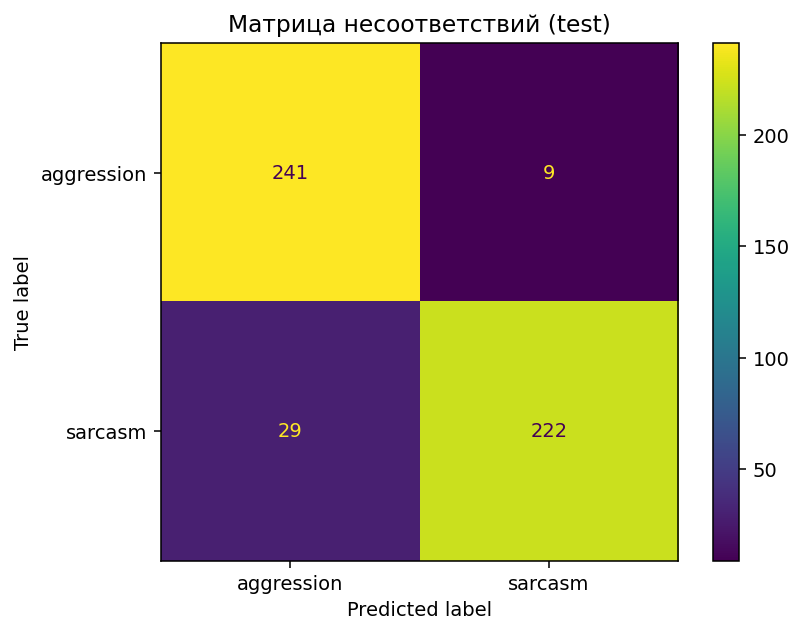

In [ ]:
disp = ConfusionMatrixDisplay.from_estimator(
    best_sgd_lr,
    X_test,
    y_test,
    display_labels=df_validation["label"].unique(),
)

plt.title("Матрица несоответствий (test)")
plt.grid(False)
plt.show()

### Поиск гиперпараметров

Произведем подбор гиперпараметров с помощью `GridSearchCV`.

In [ ]:
# Команда для отключения текущей клетки
#%%script false --no-raise-error
# Убрать вывод для текущей клетки
%%capture

parameters = {
    "clf__alpha": [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 0.1],
    "clf__eta0": [1e-4, 1e-3, 1e-2, 0.1, 1],
    "clf__tol": [1e-4, 1e-3, 1e-2],
    "clf__max_iter": [100, 500, 1000, 2000],
}

pipeline = Pipeline([
    (
        "vec",
        TfidfVectorizer(
            lowercase=True,
            min_df=3,
            ngram_range=(1, 1),
        ),
    ),
    (
        "clf",
        SGDClassifier(
            loss="log_loss",
            penalty="l2",
            learning_rate="constant",
            random_state=RANDOM_SEED,
        ),
    ),
])

clf = GridSearchCV(pipeline, parameters, n_jobs=-1)
clf.fit(X_train, y_train)

Ниже приведены наилучшие параметры, полученные после подбора.

In [ ]:
clf.best_params_

{'clf__alpha': 1e-06,
 'clf__eta0': 0.01,
 'clf__max_iter': 500,
 'clf__tol': 0.0001}

Оценка на тренировочном и валидационном датасетах для модели с полученными гиперпараметрами.

In [ ]:
y_test_pred = clf.predict(X_test)
y_val_pred = clf.predict(X_val)

print("Validation accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation macro-F1:", f1_score(y_val, y_val_pred, average="macro"), "\n")

print("Test accuracy:", accuracy_score(y_test, y_test_pred))
print("Test macro-F1:", f1_score(y_test, y_test_pred, average="macro"), "\n")

print(
    "Отчет (test):\n",
    classification_report(
        y_test,
        y_test_pred,
        target_names=df_validation["label"].unique(),
    ),
)

Validation accuracy: 0.9441117764471058
Validation macro-F1: 0.9441097724230254 

Test accuracy: 0.9321357285429142
Test macro-F1: 0.9321138211382114 

Отчет (test):
               precision    recall  f1-score   support

  aggression       0.92      0.95      0.93       250
     sarcasm       0.95      0.91      0.93       251

    accuracy                           0.93       501
   macro avg       0.93      0.93      0.93       501
weighted avg       0.93      0.93      0.93       501



Построим матрицу несоответствий.

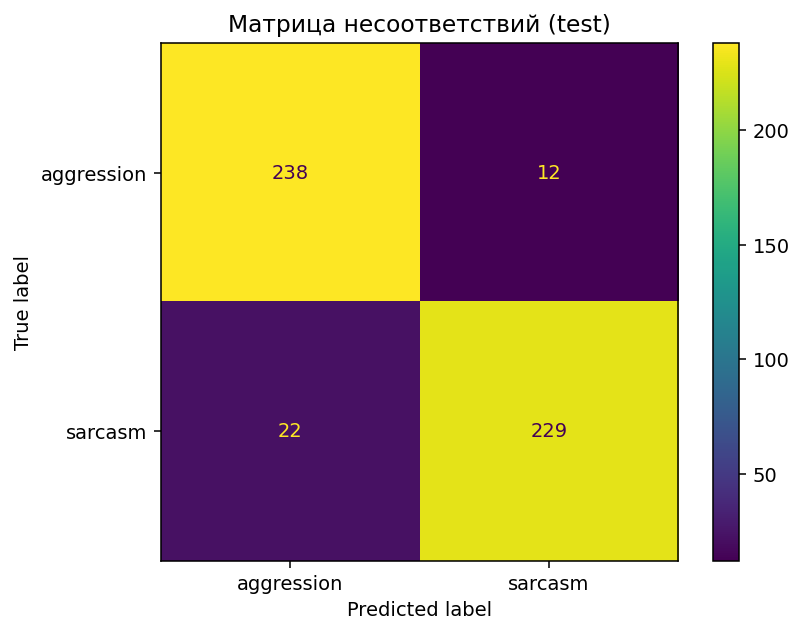

In [ ]:
disp = ConfusionMatrixDisplay.from_estimator(
    clf,
    X_test,
    y_test,
    display_labels=df_validation["label"].unique(),
)

plt.title("Матрица несоответствий (test)")
plt.grid(False)
plt.show()

### Предобработка для "мешка слов"

Предобработка будет состоять из лемматизации исходного корпуса и удаления стоп-слов. Для ускорения всего процесса возьмем валидационную выборку из исходного датасета, а также сократим количество документов до 50.

In [ ]:
nltk.download('stopwords')
russian_stopwords = stopwords.words('russian')

BASE_RU_REGEX = re.compile(r"[А-Яа-яЁё]+(?:-[А-Яа-яЁё]+)?")
simple_tokenize = lambda text, regex: regex.findall(text.lower())

lemmatize = lambda text: " ".join(
    morph.parse(t)[0].normal_form
    for t in simple_tokenize(text, BASE_RU_REGEX)
    if t not in russian_stopwords
)

morph = MorphAnalyzer()
corpus = ru_emotion_dvach_ds["validation"]["text"][:50]

corpus_lemmatized = [lemmatize(doc) for doc in corpus if doc]
corpus_lemmatized

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


['чуваш сувар',
 'обьяснить мне-на кой хер мы это средиземноморье один страна профукать второй идти удвоенный скорость никуда асад дружить год получить кроме возможность нагадить еврей почему должный продолжать возиться этот страна приносить мы проблема это всё из-за политик-идиот который мочь сделать правильно',
 'дом рф пробовать вроде рефинансировать программа',
 'аплодисменты мочь как-то повлиять работа пилот состояние самолёт',
 'махоун интересный блогер несмотря латвия эстония слово звучать оригинально интересно уверенный свой поклонник',
 'таки проиграть интернационализм вообще дурно влиять сохранение результат производство внутри страна бояться это начало проблема',
 'это полный абсурд удалёнка всё охотно выпускать это просто экономия деньга счёт сотрудник просто эксплуатировать',
 'понимать это сделать мочь попасть больший беда очень опасно',
 'ты действительно наплевать житель донбасс уверенный чувствовать эмпатия просто понимать насколько это важно',
 'неужели это вообще как

Далее загрузим предобработанный корпус в `TfidfVectorizer`.

In [ ]:
vectorizer = TfidfVectorizer(max_features=20, ngram_range=(1, 2))
X = vectorizer.fit_transform(corpus_lemmatized)
feature_names = vectorizer.get_feature_names_out()
X, feature_names

(<Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 119 stored elements and shape (50, 20)>,
 array(['бояться', 'будущее', 'быть', 'вообще', 'всё', 'который', 'мочь',
        'мы', 'один', 'очень', 'проблема', 'просто', 'такой', 'то', 'ты',
        'уверенный', 'человек', 'это', 'это просто', 'этот'], dtype=object))

Построим BoW-матрицу для визуализации результатов.

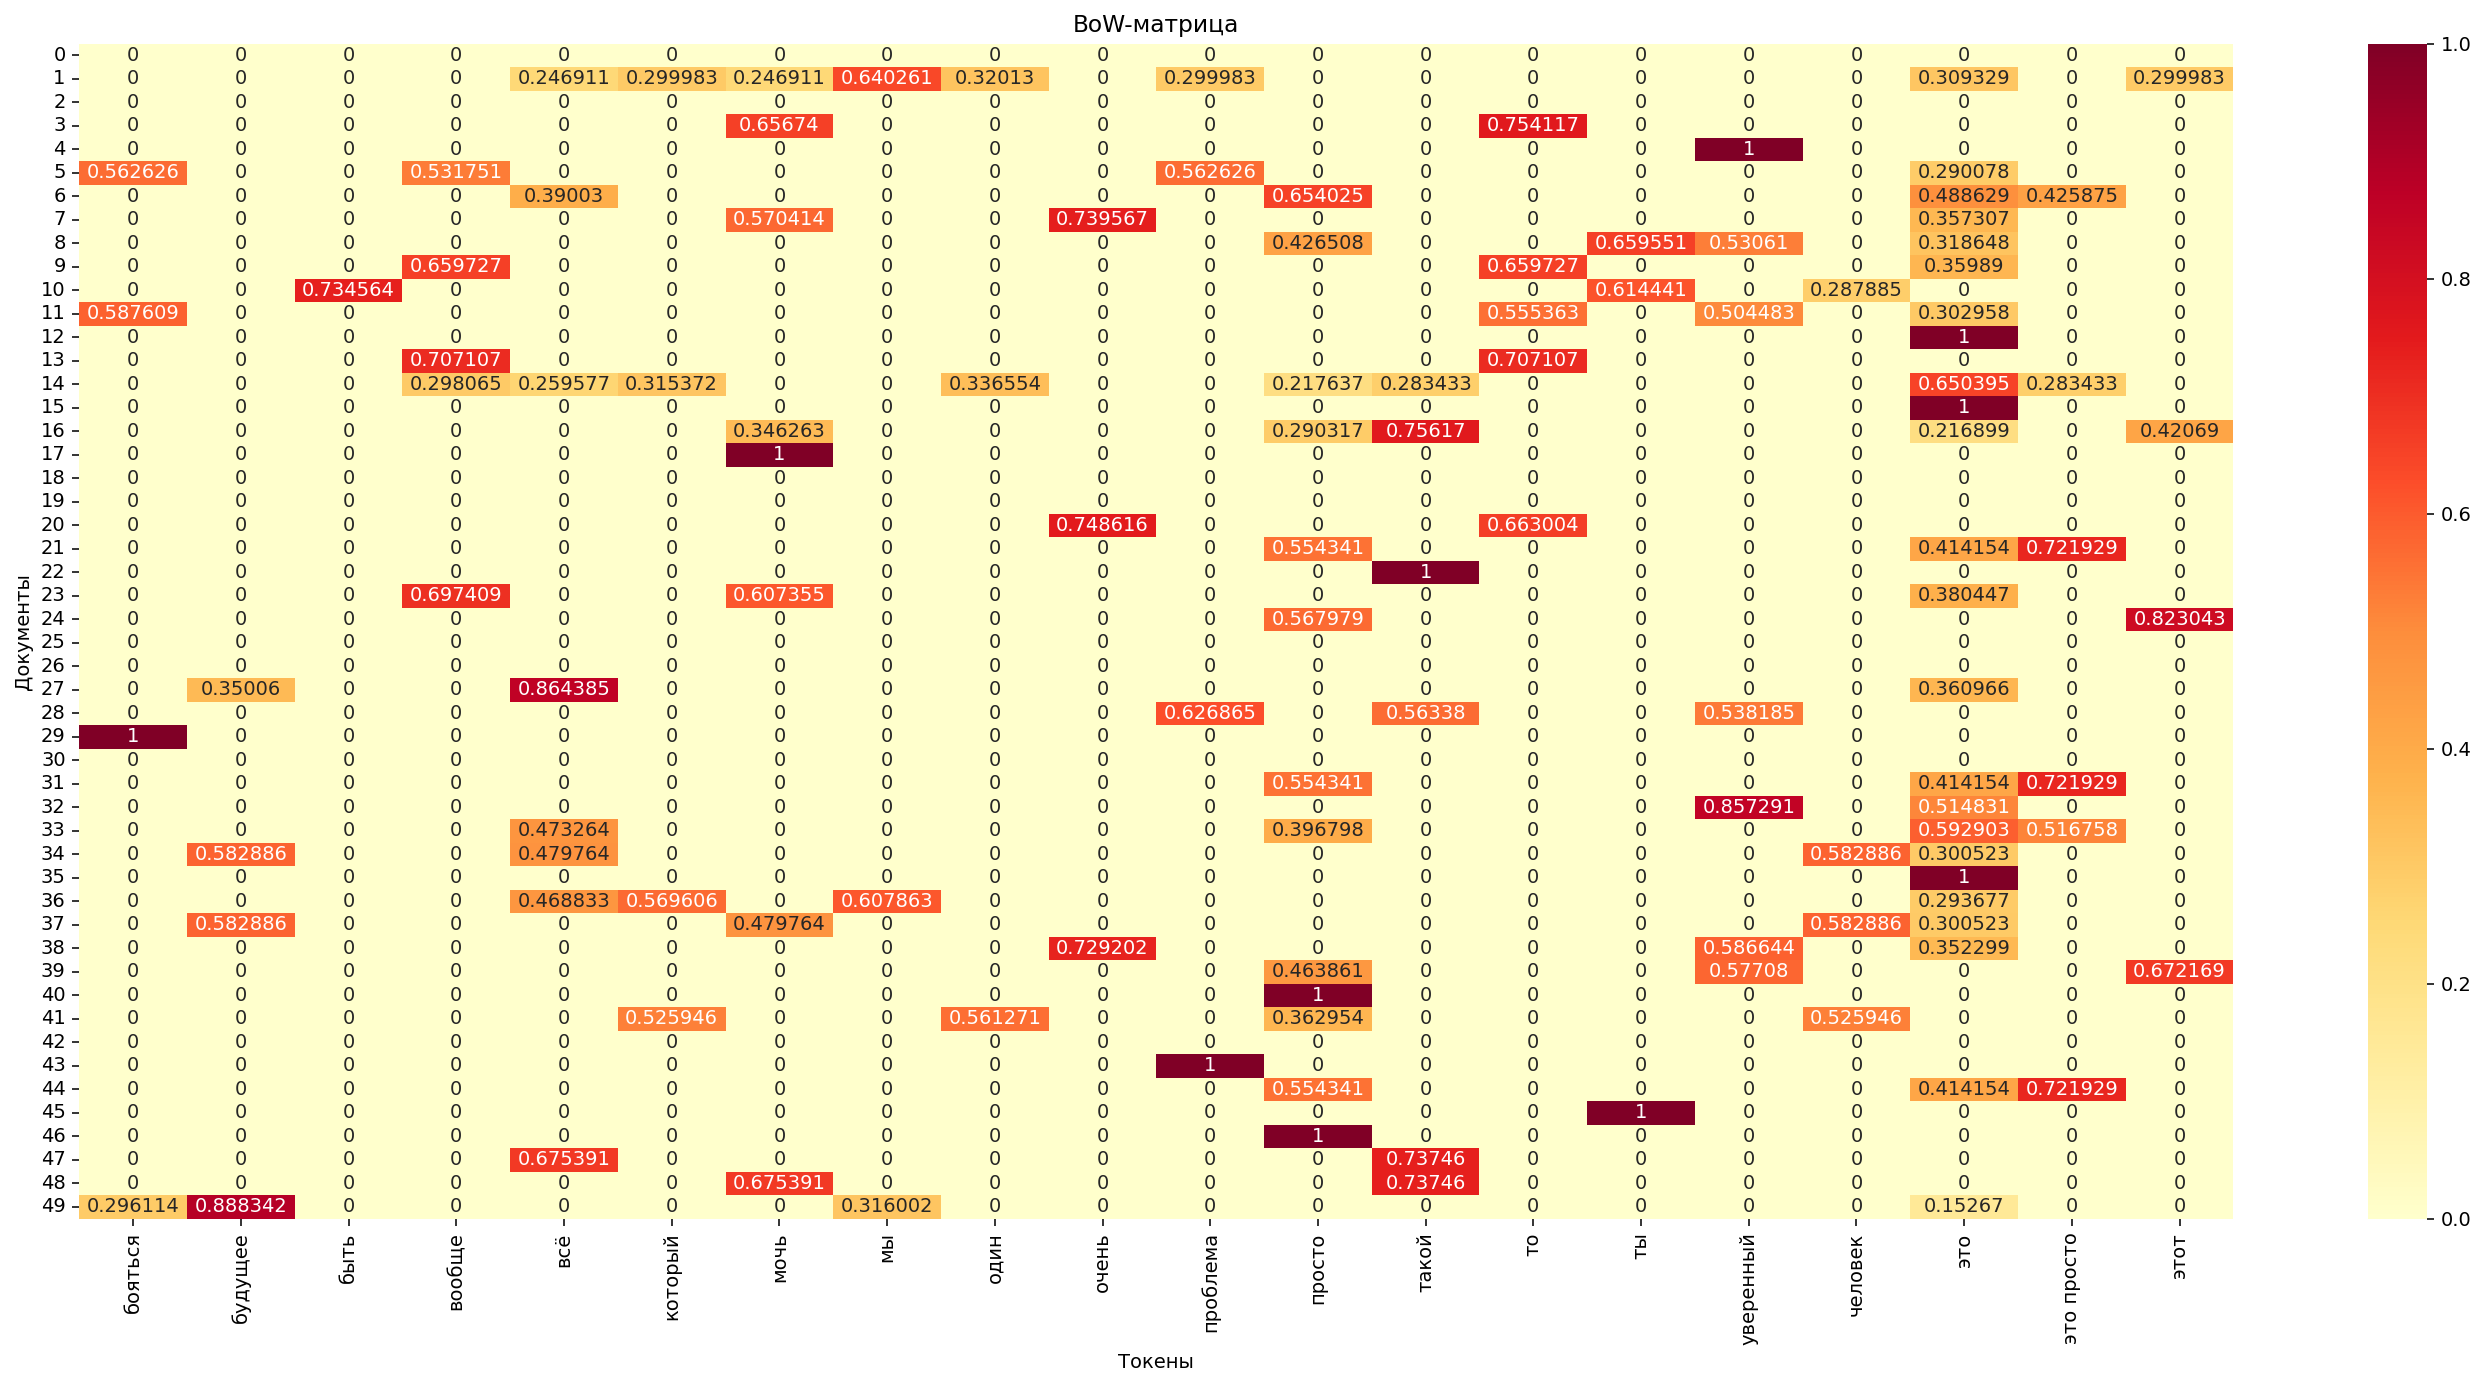

In [ ]:
df = pd.DataFrame(X.toarray(), columns=feature_names)

plt.figure(figsize=(20, 10))
sns.heatmap(df, annot=True, cmap="YlOrRd", fmt="g")
plt.title("BoW-матрица")
plt.xlabel("Токены")
plt.ylabel("Документы")
plt.tight_layout()
plt.show()

## Линейный SVM (подбор C)

Произведем подбор параметра регуляризации для линейного SVC по аналогии с логистической регрессией выше.

In [ ]:
# Убрать вывод для текущей клетки
%%capture

Cs = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 0.1, 1]
results = []

for C in Cs:
    model = Pipeline([
        (
            "vec",
            TfidfVectorizer(
                lowercase=True,
                min_df=3,
                ngram_range=(1, 1),
            ),
        ),
        (
            "clf",
            LinearSVC(
                loss="hinge",
                penalty="l2",
                C=C,
                max_iter=30,
                tol=1e-6,
                random_state=RANDOM_SEED,
            ),
        ),
    ])

    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)

    acc = accuracy_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred, average="macro")

    results.append((C, acc, f1))

Выберем лучший параметр по macro-F1.

In [ ]:
best_C, best_acc, best_f1 = sorted(
    results,
    key=lambda x: x[2],
    reverse=True
)[0]

print("Результаты (alpha, acc_val, f1_val):")

for C, acc, f1 in results:
    print(f"C={C:<8g} acc={acc:.3f}   f1_val={f1:.3f}")

print(
    "\nЛучший C:",
    best_C,
    "| acc_val:",
    best_acc,
    "| f1_val:",
    best_f1
)

Результаты (alpha, acc_val, f1_val):
C=1e-06    acc=0.645   f1_val=0.594
C=1e-05    acc=0.645   f1_val=0.594
C=0.0001   acc=0.645   f1_val=0.594
C=0.001    acc=0.645   f1_val=0.594
C=0.01     acc=0.884   f1_val=0.883
C=0.1      acc=0.922   f1_val=0.922
C=1        acc=0.936   f1_val=0.936

Лучший C: 1 | acc_val: 0.936127744510978 | f1_val: 0.9361213821241872


Обучим финальную модель с наилучшей степенью регуляризации.

In [ ]:
best_svc_lr = Pipeline([
    (
        "vec",
        TfidfVectorizer(
            lowercase=True,
            min_df=3,
            ngram_range=(1, 1),
        ),
    ),
    (
        "clf",
        LinearSVC(
            loss="hinge",
            penalty="l2",
            C=best_C,
            max_iter=30,
            tol=1e-6,
            random_state=RANDOM_SEED,
        ),
    ),
])
best_svc_lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Pipeline(steps=[('vec', TfidfVectorizer(min_df=3)),
                ('clf',
                 LinearSVC(C=1, loss='hinge', max_iter=30, random_state=52,
                           tol=1e-06))])

Оценка на валидационной/тестовой выборках для лучшей модели.

In [ ]:
y_val_pred = best_svc_lr.predict(X_val)
y_test_pred = best_svc_lr.predict(X_test)

print("Validation accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation macro-F1:", f1_score(y_val, y_val_pred, average="macro"), "\n")
print("Test accuracy:", accuracy_score(y_test, y_test_pred))
print("Test macro-F1:", f1_score(y_test, y_test_pred, average="macro"))

print(
    "\nОтчет (test):\n",
    classification_report(
        y_test,
        y_test_pred,
        target_names=df_validation["label"].unique()
    ),
)

Validation accuracy: 0.936127744510978
Validation macro-F1: 0.9361213821241872 

Test accuracy: 0.9281437125748503
Test macro-F1: 0.9281205164992827

Отчет (test):
               precision    recall  f1-score   support

  aggression       0.91      0.95      0.93       250
     sarcasm       0.95      0.91      0.93       251

    accuracy                           0.93       501
   macro avg       0.93      0.93      0.93       501
weighted avg       0.93      0.93      0.93       501



Построим матрицу несоответствий.

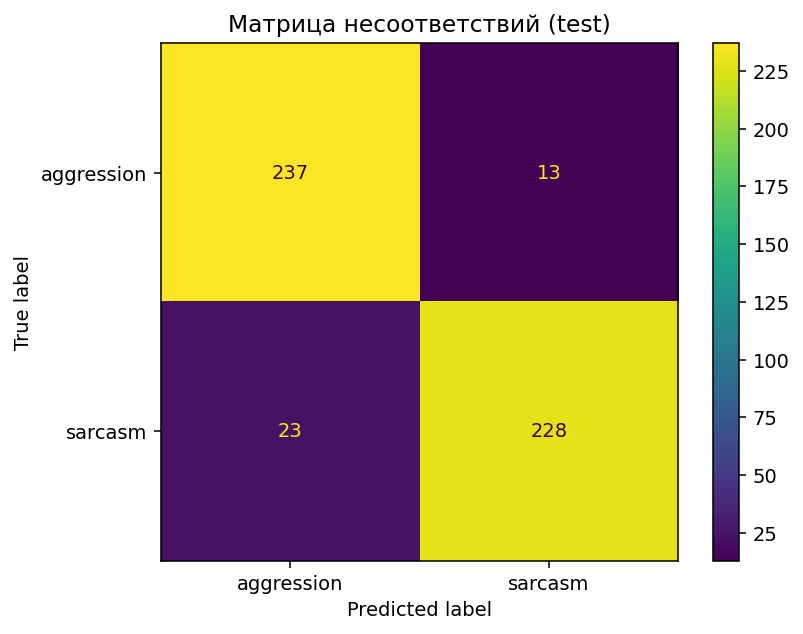

In [ ]:
disp = ConfusionMatrixDisplay.from_estimator(
    best_svc_lr,
    X_test,
    y_test,
    display_labels=df_validation["label"].unique(),
)

plt.title("Матрица несоответствий (test)")
plt.grid(False)
plt.show()

## Добавление L1-регуляризации. Вывод топ-признаков

Произведем тренировку моделей с разными параметрами $\alpha$ для дальнейшего выбора наилучшего.

In [ ]:
# Убрать вывод для текущей клетки
%%capture

alphas = np.logspace(-6, -2, 5)

models_by_alpha = {}
results_l1 = []

for a in alphas:
    model = Pipeline([
        (
            "vec",
            TfidfVectorizer(
                lowercase=True,
                min_df=3,
                ngram_range=(1, 1),
            ),
        ),
        (
            "clf",
            SGDClassifier(
                loss="log_loss",
                penalty="l1",
                alpha=a,
                learning_rate="constant",
                eta0=0.02,
                max_iter=50,
                tol=1e-6,
                random_state=RANDOM_SEED,
            ),
        ),
    ])

    model.fit(X_train, y_train)
    models_by_alpha[a] = model

    y_val_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred, average="macro")

    coef = model.named_steps["clf"].coef_.ravel()
    sparsity = (coef == 0).mean()

    results_l1.append((a, acc, f1, sparsity))

Лучший параметр $\alpha$ по F1-macro.

In [ ]:
print("alpha       acc_val   f1_val   sparsity")

for a, acc, f1, sparsity in results_l1:
    print(f"{a:<10g} {acc:>7.3f} {f1:>8.3f} {sparsity:>10.3f}")

best_alpha = max(results_l1, key=lambda x: x[2])[0]
best_l1 = models_by_alpha[best_alpha]

print("\nЛучший alpha по F1:", best_alpha)

alpha       acc_val   f1_val   sparsity
1e-06        0.934    0.934      0.129
1e-05        0.940    0.940      0.729
0.0001       0.910    0.910      0.984
0.001        0.872    0.872      0.998
0.01         0.695    0.665      1.000

Лучший alpha по F1: 1e-05


Сбалансированный $\alpha$ по F1.

In [ ]:
best_balanced_alpha_l1, best_balanced_acc_l1, best_balanced_f1_l1, best_balanced_sp_l1 = results_l1[2]
best_balanced_l1 = models_by_alpha[best_balanced_alpha_l1]

print(
    "Сбалансированный alpha по F1:",
    best_balanced_alpha_l1,
    "| f1_val:",
    best_balanced_f1_l1,
    "| sparcity:",
    best_balanced_sp_l1,
)

Сбалансированный alpha по F1: 0.0001 | f1_val: 0.9101094475787963 | sparcity: 0.9842998874910505


Точность и macro-F1 (L1) на тестовой выборке.

In [ ]:
y_test_pred_l1 = best_balanced_l1.predict(X_test)

print("Test accuracy (L1):", accuracy_score(y_test, y_test_pred_l1))
print("Test macro-F1 (L1):", f1_score(y_test, y_test_pred_l1, average="macro"))

Test accuracy (L1): 0.8982035928143712
Test macro-F1 (L1): 0.8980411091735467


Важные признаки (топ-слова), доля нулевых весов и топ признаков, увеличиваюие p(y=1) и p(y=0).

In [ ]:
vec_l1 = best_balanced_l1.named_steps["vec"]
clf_l1 = best_balanced_l1.named_steps["clf"]

feature_names = np.array(vec_l1.get_feature_names_out())
coef = clf_l1.coef_.ravel()

zero_frac = (coef == 0).mean()

print(f"Доля нулевых весов (sparcity): {zero_frac:.3f}")

top_k = 20

pos_idx = np.argsort(coef)[-top_k:][::-1]
neg_idx = np.argsort(coef)[:top_k]

print(f"\nТоп-{top_k} признаков, увеличивающих p(y=1):")
for w, c in zip(feature_names[pos_idx], coef[pos_idx]):
    print(f"{w:>20s}  {c: .3f}")

print(f"\nТоп-{top_k} признаков, увеличивающих p(y=0):")
for w, c in zip(feature_names[neg_idx], coef[neg_idx]):
    print(f"{w:>20s}  {c: .3f}")

Доля нулевых весов (sparcity): 0.984

Топ-20 признаков, увеличивающих p(y=1):
             конечно   22.863
                  ну   16.293
            наверное   16.147
        замечательно   9.910
               может   8.913
            особенно   8.596
            подумать   8.326
            смотрите   7.902
                ведь   7.659
              видимо   7.485
              правда   7.346
                 как   6.245
           интересно   6.127
             великий   5.667
                  же   5.405
                  ха   5.355
               гений   5.034
                  oh   4.804
               будто   4.706
               какая   4.542

Топ-20 признаков, увеличивающих p(y=0):
              полный  -8.942
              вообще  -7.864
              идиоты  -7.755
              совсем  -7.557
      издевательство  -6.610
                 эти  -5.726
                бред  -5.543
              полное  -5.428
               идиот  -4.885
                 это  -4.806
        

## Char n-grams TF-IDF. Сравнение с word TF-IDF

Далее сравним `TfidfVectorizer` по словам и n-граммам. В качестве параметра $\alpha$ возьмем наилучший, найденный ранее.

In [ ]:
words_pipeline = Pipeline([
    (
        "vec",
        TfidfVectorizer(
            lowercase=True,
            min_df=3,
            analyzer="word"
        ),
    ),
    (
        "clf",
        SGDClassifier(
            loss="log_loss",
            penalty="l1",
            alpha=best_alpha,
            learning_rate="constant",
            eta0=0.02,
            max_iter=50,
            tol=1e-6,
            random_state=RANDOM_SEED,
        ),
    ),
])

ngram_pipeline = Pipeline([
    (
        "vec",
        TfidfVectorizer(
            lowercase=True,
            min_df=3,
            analyzer="char",
            ngram_range=(2, 5),
        ),
    ),
    (
        "clf",
        SGDClassifier(
            loss="log_loss",
            penalty="l1",
            alpha=best_alpha,
            learning_rate="constant",
            eta0=0.02,
            max_iter=50,
            tol=1e-6,
            random_state=RANDOM_SEED,
        ),
    ),
])

words_pipeline.fit(X_train, y_train)
ngram_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Pipeline(steps=[('vec',
                 TfidfVectorizer(analyzer='char', min_df=3,
                                 ngram_range=(2, 5))),
                ('clf',
                 SGDClassifier(alpha=np.float64(1e-05), eta0=0.02,
                               learning_rate='constant', loss='log_loss',
                               max_iter=50, penalty='l1', random_state=52,
                               tol=1e-06))])

Далее сравним полученные результаты.

In [ ]:
def print_report(pipeline, X, y, label="TEST"):
    y_pred = pipeline.predict(X)

    print(f"{label} accuracy:", accuracy_score(y, y_pred))
    print(f"{label} macro-F1:", f1_score(y, y, average="macro"))

    print(
        f"\nОтчет ({label}):\n",
        classification_report(
            y,
            y_pred,
            target_names=df_validation["label"].unique()
        ),
    )


print_report(words_pipeline, X_val, y_val, "VAL")
print_report(ngram_pipeline, X_val, y_val, "VAL")

VAL accuracy: 0.9401197604790419
VAL macro-F1: 1.0

Отчет (VAL):
               precision    recall  f1-score   support

  aggression       0.92      0.97      0.94       250
     sarcasm       0.97      0.91      0.94       251

    accuracy                           0.94       501
   macro avg       0.94      0.94      0.94       501
weighted avg       0.94      0.94      0.94       501

VAL accuracy: 0.9301397205588823
VAL macro-F1: 1.0

Отчет (VAL):
               precision    recall  f1-score   support

  aggression       0.90      0.96      0.93       250
     sarcasm       0.96      0.90      0.93       251

    accuracy                           0.93       501
   macro avg       0.93      0.93      0.93       501
weighted avg       0.93      0.93      0.93       501



## Вывод

Полученные наилучшие параметры $C$ и $\alpha$: 1 и 1e-6 соответственно. Приблизительное соотношение этих двух параметров можно выразить следующим образом:

$$
C \approx \frac{1}{\alpha \times n}
$$

Следовательно, в то время как $\alpha$ стремится к нулю, $C$ стремится к бесконечности.

Исходя из полученных метрик, линейный SVM классифицировал отобранные интенты лучше, чем логистическая регрессия.

Наилучшие параметры, полученные с помощью `GridSearchCV`:

- alpha: 1e-06
- eta0: 0.01
- max_iter: 500
- tol: 0.0001

Полученные топ-20 слов в полной мере характеризуют целевые классы (агрессия и сарказм), слово "конечно" в топе для класса "сарказм", поскольку используется не только в положительном, но и в саркастическом ключе. Также всего $~1,6\%$ весов пригодны для классификации, оставшиеся $~98\%$ – шум.

При сравнении символьного и словестного n-грам векторайзера разницы в производительности обнаружено не было.